sasho beshe tuk

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import scipy.stats as stats
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV


In [93]:
df = pd.read_parquet('./bird_habitats_weather.parquet')

### Sampling

In [94]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,2,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,3,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,4,380,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5,380,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0


In [95]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
count,1.255876e+07,1.255876e+07,12558756,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.255876e+07,1.255876e+07,1.253764e+07,1.253764e+07,1.253764e+07,1.253764e+07,1.253608e+07,1.253764e+07,1.253630e+07,1.253630e+07
mean,5.223006e+01,5.532783e+00,2017-12-31 11:59:59.999999,8.067763e+00,4.330658e+00,5.143431e-02,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,...,1.831253e+02,2.989088e+02,1.088453e+01,6.726166e+00,1.481465e+01,2.228206e+00,4.141858e+00,8.026855e+01,5.079891e+00,1.067049e+03
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e+00,2.400000e+02,-1.270000e+01,-1.950000e+01,-6.700000e+00,0.000000e+00,0.000000e+00,2.900000e+01,0.000000e+00,2.000000e+01
25%,5.170000e+01,4.900000e+00,2013-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,...,9.200000e+01,2.600000e+02,6.400000e+00,2.600000e+00,9.300000e+00,0.000000e+00,2.600000e+00,7.400000e+01,1.200000e+00,3.340000e+02
50%,5.220000e+01,5.650000e+00,2017-12-31 12:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,...,1.830000e+02,2.800000e+02,1.080000e+01,6.900000e+00,1.470000e+01,1.000000e-01,3.700000e+00,8.200000e+01,4.400000e+00,9.030000e+02
75%,5.280000e+01,6.200000e+00,2021-12-31 06:00:00,6.000000e+00,2.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,...,2.740000e+02,3.300000e+02,1.580000e+01,1.120000e+01,2.030000e+01,2.400000e+00,5.200000e+00,8.800000e+01,8.200000e+00,1.674000e+03
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,2.779000e+03,1.090000e+02,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,...,3.660000e+02,3.910000e+02,3.090000e+01,2.350000e+01,4.020000e+01,1.064000e+02,1.800000e+01,1.000000e+02,1.570000e+01,3.130000e+03
std,6.605211e-01,8.748856e-01,NaN,3.912502e+01,1.606794e+01,3.364980e-01,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,...,1.054386e+02,4.632105e+01,6.218839e+00,5.777645e+00,7.255706e+00,4.617264e+00,2.101596e+00,1.033570e+01,4.252923e+00,8.067607e+02


### Filtering the data based on date

In [96]:
df_filtered = df[df['eventDate'].dt.year > 2019]

In [97]:
df_filtered.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
3652,50.75,5.65,2020-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-0.6,-3.2,2.9,0.0,1.9,99.0,2.7,318.0
3653,50.75,5.65,2020-01-02,2.0,2,0,1.7747,0.0568,0.0,0.0616,...,2,380,3.5,-0.6,7.4,0.0,4.5,89.0,1.3,178.0
3654,50.75,5.65,2020-01-03,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,3,380,7.5,3.5,9.4,4.9,5.8,92.0,0.0,71.0
3655,50.75,5.65,2020-01-04,10.0,9,1,1.7747,0.0568,0.0,0.0616,...,4,380,5.0,2.5,6.9,0.1,3.6,90.0,1.9,237.0
3656,50.75,5.65,2020-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5,380,5.9,5.2,7.0,0.0,3.0,84.0,0.0,116.0


In [98]:
df_filtered.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
Phalacrocorax carbo                   int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                              

In [99]:
df_filtered.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,361,280,3.4,-2.4,7.2,0.0,2.2,90.0,0.5,126.0
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,362,280,0.3,-3.2,4.4,0.0,1.4,97.0,1.7,198.0
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,363,280,5.2,1.1,7.4,0.2,3.3,83.0,0.5,141.0
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,364,280,3.2,-2.1,6.4,0.1,3.0,70.0,5.1,295.0
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,365,280,4.0,-1.1,7.4,0.1,5.2,89.0,1.7,195.0


### Creating the seen column

In [100]:
# df_filtered['sasho'] = pd.to_numeric(pd.to_datetime(df_filtered['eventDate']))
# df_filtered['sasho1'] = pd.to_numeric(pd.to_datetime(df_filtered['date']))

In [101]:
df_filtered['seen'] = (df_filtered['Phalacrocorax carbo'] > 0).astype(int)

### Splitting the data

In [102]:
X = df_filtered.drop(columns=['Phalacrocorax carbo','seen'])
y = df_filtered['seen']

train_mask = df_filtered['eventDate'].dt.year <= 2023      # train 2020-2023
X_train, X_test = X[train_mask], X[~train_mask]            # test  2024-2025
y_train, y_test = y[train_mask], y[~train_mask]

In [103]:
X_train.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,day_of_year,STN,TG,TN,TX,RH,FG,UG,SQ,Q
3652,50.75,5.65,2020-01-01,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,1,380,-0.6,-3.2,2.9,0.0,1.9,99.0,2.7,318.0
3653,50.75,5.65,2020-01-02,2.0,2,1.7747,0.0568,0.0,0.0616,0.0582,...,2,380,3.5,-0.6,7.4,0.0,4.5,89.0,1.3,178.0
3654,50.75,5.65,2020-01-03,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,3,380,7.5,3.5,9.4,4.9,5.8,92.0,0.0,71.0
3655,50.75,5.65,2020-01-04,10.0,9,1.7747,0.0568,0.0,0.0616,0.0582,...,4,380,5.0,2.5,6.9,0.1,3.6,90.0,1.9,237.0
3656,50.75,5.65,2020-01-05,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,5,380,5.9,5.2,7.0,0.0,3.0,84.0,0.0,116.0


In [104]:
X_train.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                                  float64
UG                              

In [105]:
y_train.head(5)

3652    0
3653    0
3654    0
3655    1
3656    0
Name: seen, dtype: int64

### Baseline model

In [118]:
from sklearn.ensemble import RandomForestClassifier

# Tuned hyperparameters settings

baseModel = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    min_samples_leaf=50,
    max_features="log2",
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Feature-leak fix: drop speciesgroup_observations
drop_cols = ['eventDate', 'main_habitat', 'speciesgroup_observations']
X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore')
X_test_numeric = X_test.drop(columns=drop_cols, errors='ignore')

baseModel.fit(X_train_numeric, y_train)
print(baseModel.predict(X_test_numeric))

[1 1 0 ... 0 0 0]


In [107]:
import sklearn.metrics as skm
from sklearn.metrics import roc_curve, auc

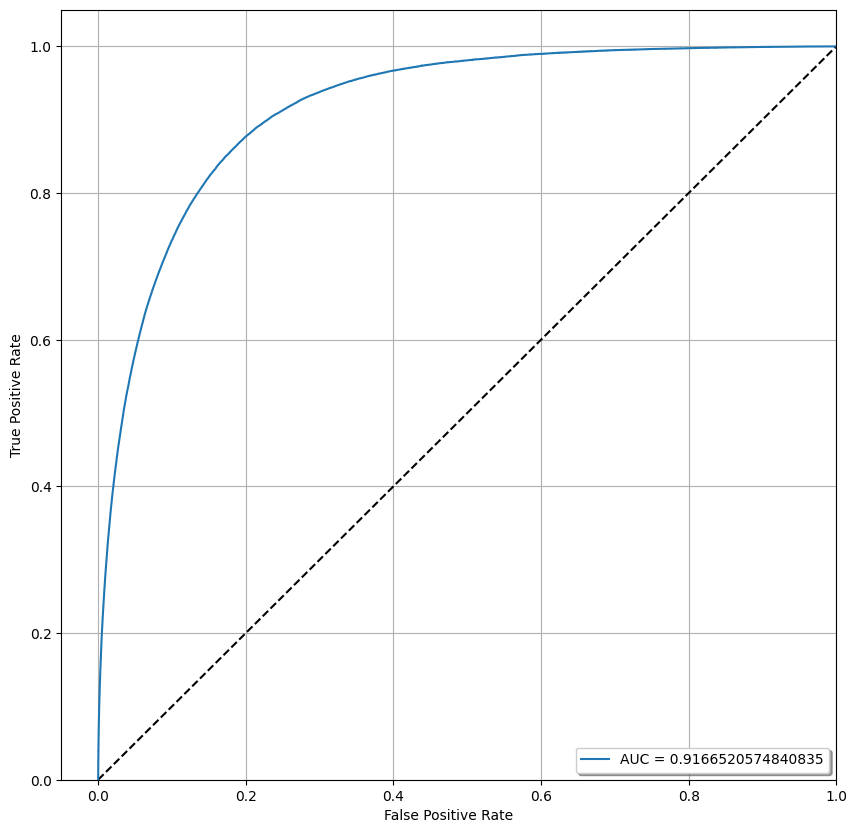

In [108]:
acc = baseModel.score(X_test_numeric,y_test)

Y_score = baseModel.predict_proba(X_test_numeric)[:,1]
fpr = dict()
tpr = dict()
fpr, tpr, sasho  = roc_curve(y_test, Y_score)

roc_auc = dict()
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.plot(fpr, tpr, label='AUC = {0}'.format(roc_auc))
plt.legend(loc="lower right", shadow=True, fancybox =True) 
plt.show()

In [109]:
print(acc)

0.8598699232742109


In [110]:
y_pred = baseModel.predict(X_test_numeric)

report = classification_report(y_test, y_pred)

In [111]:
print(report)

              precision    recall  f1-score   support

           0       0.99      0.86      0.92   1480603
           1       0.26      0.80      0.40     90316

    accuracy                           0.86   1570919
   macro avg       0.63      0.83      0.66   1570919
weighted avg       0.94      0.86      0.89   1570919



crazy burger model

In [113]:
def burger_model(row): 
    return 0

class AlwaysZeroModel:
    def fit(self, X, y):
        pass  # Do nothing, ignore the data

    def predict(self, X):
        return [0] * len(X)  # Return a 0 for every row in the input

In [114]:
df_eval = df_filtered.copy()
df_eval['predicted_seen'] = df_eval.apply(lambda row: burger_model(row), axis=1)

y_true = df_filtered["seen"]
y_pred = df_eval["predicted_seen"]

In [115]:
report = classification_report(y_true, y_pred)

C:\Users\User\Desktop\steam-inv-watcher\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\steam-inv-watcher\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\steam-inv-watcher\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [116]:
print(report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97   4457739
           1       0.00      0.00      0.00    252869

    accuracy                           0.95   4710608
   macro avg       0.47      0.50      0.49   4710608
weighted avg       0.90      0.95      0.92   4710608

